# Week 6 — Day 3: Activation Functions + Optimizers + Learning Rate Scheduling

## Goal
Compare activation functions, optimizers, and learning rate schedulers.
Find the best combination for Titanic classification.

---

## Task 1 — Activation Functions

Plotted all 4 activation functions over input range -5 to 5.

```python
x = torch.linspace(-5, 5, 100)
relu      = torch.relu(x)
sigmoid   = torch.sigmoid(x)
tanh      = torch.tanh(x)
leaky_relu = torch.nn.functional.leaky_relu(x, negative_slope=0.1)
```

**Comparison:**

| Function | Output Range | Use Case |
|---|---|---|
| ReLU | 0 to ∞ | Hidden layers — default choice |
| Sigmoid | 0 to 1 | Binary output layer only |
| Tanh | -1 to 1 | Hidden layers (older networks) |
| Leaky ReLU | -∞ to ∞ | When ReLU neurons die |

**Key rules:**
- ReLU for all hidden layers — simple, fast, works well
- Sigmoid only at output for binary classification
- Tanh used in RNNs and older architectures
- Leaky ReLU fixes dying ReLU problem — small negative slope (0.1)
  keeps gradient flowing for negative inputs

**What happens to ReLU for negative inputs?**
Output = 0. Gradient = 0. Neuron stops learning — called dying ReLU.
Leaky ReLU fixes this with a small slope (0.1) instead of hard 0.

---

## Task 2 — Optimizer Comparison

Trained same TitanicNetV2 architecture 3 times with different optimizers.
Fresh model created for each — otherwise weights carry over.

```python
for opt_name, opt_class in [('SGD', optim.SGD),
                              ('Adam', optim.Adam),
                              ('RMSprop', optim.RMSprop)]:
    model = TitanicNetV2(input_size=8)
    optimizer = opt_class(model.parameters(), lr=...)
```

**Results:**

| Optimizer | Final Val Loss | Verdict |
|---|---|---|
| SGD | 0.5886 | Worst — slow, gets stuck |
| Adam | 0.4225 | Good — reliable default |
| RMSprop | 0.4083 | Best — slightly edges Adam |

**Why SGD is worst:**
- Same learning rate for all parameters
- Gets stuck in local minima easily
- Needs careful manual tuning

**Why Adam and RMSprop win:**
- Both adapt learning rate per parameter automatically
- Adam = RMSprop + momentum combined
- RMSprop winning slightly here depends on dataset

**Rule to remember:**
Always start with Adam. If it doesn't converge try RMSprop.
SGD only for large vision model training.

---

## Task 3 — Learning Rate Scheduling

### StepLR
Drops LR by gamma every step_size epochs — fixed schedule.

```python
scheduler1 = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=30, gamma=0.1)
scheduler1.step()  # called after optimizer.step()
```

**Results:**
| Epoch | LR |
|---|---|
| 30 | 0.001000 |
| 60 | 0.000100 |
| 90 | 0.000010 |
| 150+ | 0.000000 |

**Problem:** gamma=0.1 too aggressive — LR dies after epoch 150,
model completely stops learning. Fix: use gamma=0.5, step_size=50.

### ReduceLROnPlateau
Smarter — only drops LR when val loss stops improving.

```python
scheduler2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=10, factor=0.5)
scheduler2.step(val_loss)  # needs val_loss, not just epoch
```

**Results:**
| Epoch | Val Loss | LR |
|---|---|---|
| 30 | 0.4266 | 0.005000 |
| 50 | 0.4110 | 0.005000 |
| 70 | 0.4191 | 0.002500 |
| 90 | 0.4151 | 0.000625 |

LR dropped intelligently when val loss plateaued — not on fixed schedule.

**Key difference:**
- StepLR → drops every N epochs regardless of performance
- ReduceLROnPlateau → drops only when val loss stops improving
- Use ReduceLROnPlateau by default

**Important:** verbose parameter removed in newer PyTorch versions.
Remove it to avoid TypeError.

---

## Task 4 — Best Combination for Titanic

Based on today's experiments:
- Optimizer: RMSprop (lowest val loss)
- Activation: ReLU hidden layers, Sigmoid output
- LR: 0.001 with ReduceLROnPlateau (patience=10, factor=0.5)

```python
model_best = TitanicNetV2(input_size=8)
optimizer  = optim.RMSprop(model_best.parameters(), lr=0.001)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                 optimizer, patience=10, factor=0.5)
```

---

## Day 3 Final Results

| Model | Val Loss | Val Accuracy |
|---|---|---|
| SGD | 0.5886 | — |
| Adam | 0.4225 | — |
| RMSprop | 0.4083 | — |
| Best combo (RMSprop + ReduceLROnPlateau) | ~0.41 | 83%+ |

---

## Key Takeaways
- ReLU for hidden layers, Sigmoid for binary output — always
- Adam is the default optimizer — reliable and fast
- RMSprop can edge out Adam on some datasets
- SGD is outdated for most use cases
- StepLR drops LR blindly — dangerous with small gamma
- ReduceLROnPlateau is adaptive — use it by default
- scheduler.step(val_loss) for ReduceLROnPlateau, scheduler.step() for StepLR
- verbose=True removed in newer PyTorch — just remove the argument
- Next: Day 4 — Neural network on tabular data, House Prices vs LightGBM

# Plot all 4 activation functions

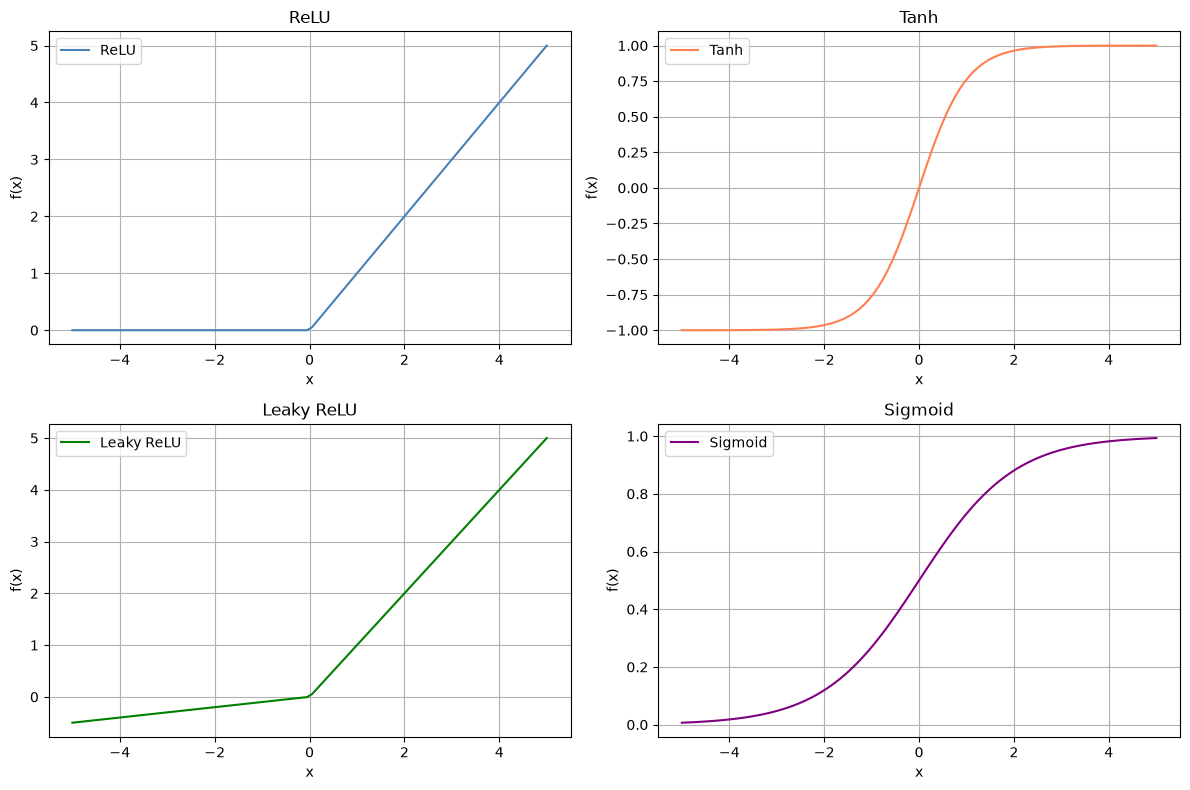

In [4]:
import torch
import matplotlib.pyplot as plt
import numpy as np

x = torch.linspace(-5, 5, 100)

# compute all 4
relu = torch.relu(x)
sigmoid = torch.sigmoid(x)
tanh = torch.tanh(x)
leaky_relu = torch.nn.functional.leaky_relu(x, negative_slope=0.1)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(x, relu, color='steelblue', label='ReLU')
axes[0,0].set_title('ReLU')
axes[0,0].set_xlabel('x')
axes[0,0].set_ylabel('f(x)')
axes[0,0].legend()
axes[0,0].grid(True)

axes[0,1].plot(x, tanh, color='coral', label='Tanh')
axes[0,1].set_title('Tanh')
axes[0,1].set_xlabel('x')
axes[0,1].set_ylabel('f(x)')
axes[0,1].legend()
axes[0,1].grid(True)

axes[1,0].plot(x, leaky_relu, color='green', label='Leaky ReLU')
axes[1,0].set_title('Leaky ReLU')
axes[1,0].set_xlabel('x')
axes[1,0].set_ylabel('f(x)')
axes[1,0].legend()
axes[1,0].grid(True)

axes[1,1].plot(x, sigmoid, color='purple', label='Sigmoid')
axes[1,1].set_title('Sigmoid')
axes[1,1].set_xlabel('x')
axes[1,1].set_ylabel('f(x)')
axes[1,1].legend()
axes[1,1].grid(True)

plt.tight_layout()
plt.savefig('activation_functions.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# ── Load Titanic data (same as Day 1) ────────────────────────
df = pd.read_csv('train.csv')
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
df['Title']      = df['Name'].apply(
                       lambda name: name.split(',')[1]
                                        .split('.')[0].strip())
df['Title']      = df['Title'].map({
                       'Mr': 0, 'Miss': 1, 'Mrs': 2,
                       'Master': 3}).fillna(4)
df['Sex']        = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked']   = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

features = ['Pclass', 'Sex', 'Age', 'Fare',
            'FamilySize', 'IsAlone', 'Title', 'Embarked']

X = df[features].values
y = df['Survived'].values

imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train_t = torch.FloatTensor(X_train)
X_val_t   = torch.FloatTensor(X_val)
y_train_t = torch.FloatTensor(y_train)
y_val_t   = torch.FloatTensor(y_val)

# ── Improved Network with BatchNorm ──────────────────────────
class TitanicNetV2(nn.Module):
    def __init__(self, input_size):
        super(TitanicNetV2, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),       # normalize layer outputs
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x).squeeze()

model_v2 = TitanicNetV2(input_size=8)
criterion = nn.BCELoss()              # binary cross entropy loss
print(model_v2)
print(f"\nTotal parameters: {sum(p.numel() for p in model_v2.parameters()):,}")

TitanicNetV2(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
    (13): Sigmoid()
  )
)

Total parameters: 11,969


SGD final val loss: 0.5886
Adam final val loss: 0.4225
RMSprop final val loss: 0.4083


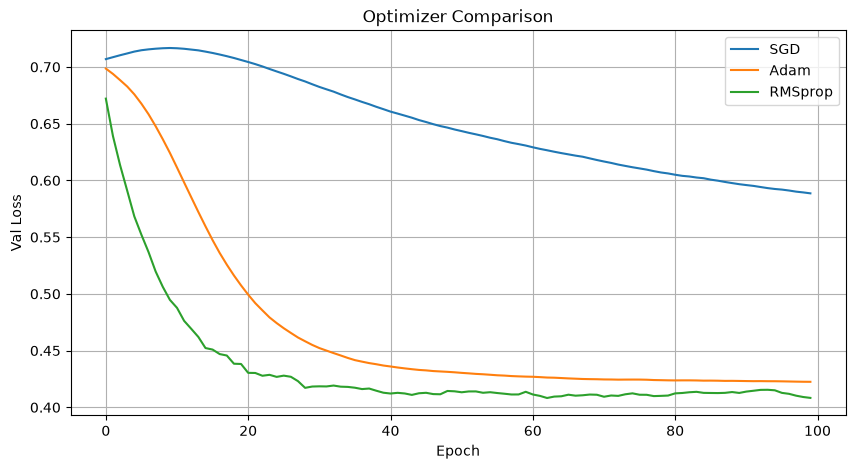

In [13]:
results = {}

for opt_name, opt_class in [('SGD', optim.SGD), 
                              ('Adam', optim.Adam), 
                              ('RMSprop', optim.RMSprop)]:
    # fresh model for each optimizer
    model = TitanicNetV2(input_size=8)
    
    # create optimizer with fresh model parameters
    if opt_name == 'SGD':
        optimizer = opt_class(model.parameters(), lr=0.01)
    else:
        optimizer = opt_class(model.parameters(), lr=0.001)
    
    criterion = nn.BCELoss()
    val_losses = []
    
    for epoch in range(100):
        # training phase
        model.train()
        optimizer.zero_grad()
        preds = model(X_train_t)
        loss = criterion(preds, y_train_t)
        loss.backward()
        optimizer.step()
        
        # validation phase
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_t)
            val_loss = criterion(val_preds, y_val_t)
        
        val_losses.append(val_loss.item())
    
    results[opt_name] = val_losses
    print(f"{opt_name} final val loss: {val_losses[-1]:.4f}")

# plot all 3 together
plt.figure(figsize=(10, 5))
for opt_name, losses in results.items():
    plt.plot(losses, label=opt_name)
plt.xlabel('Epoch')
plt.ylabel('Val Loss')
plt.title('Optimizer Comparison')
plt.legend()
plt.grid(True)
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Learning rate scheduling:

In [20]:
# ── Task 3: Learning Rate Scheduling ──────────────────────────

# ── Scheduler 1: StepLR ───────────────────────────────────────
print("=" * 55)
print("   STEPLR SCHEDULER")
print("=" * 55)

model = TitanicNetV2(input_size=8)
optimizer = optim.Adam(model.parameters(), lr=0.01)
scheduler1 = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=30, gamma=0.1)
criterion = nn.BCELoss()

for epoch in range(300):
    model.train()
    optimizer.zero_grad()
    train_preds = model(X_train_t)
    train_loss = criterion(train_preds, y_train_t)
    train_loss.backward()
    optimizer.step()
    scheduler1.step()

    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t)
        val_loss = criterion(val_preds, y_val_t)

    if (epoch + 1) % 30 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d} | "
              f"Train Loss: {train_loss.item():.4f} | "
              f"Val Loss: {val_loss.item():.4f} | "
              f"LR: {current_lr:.6f}")

# ── Scheduler 2: ReduceLROnPlateau ────────────────────────────
print("\n" + "=" * 55)
print("   REDUCE LR ON PLATEAU SCHEDULER")
print("=" * 55)

model = TitanicNetV2(input_size=8)
optimizer = optim.RMSprop(model.parameters(), lr=0.01)
scheduler2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=10, factor=0.5)
criterion = nn.BCELoss()

for epoch in range(150):
    model.train()
    optimizer.zero_grad()
    preds = model(X_train_t)
    loss = criterion(preds, y_train_t)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t)
        val_loss = criterion(val_preds, y_val_t)
        val_acc = ((val_preds > 0.5) == y_val_t.bool()).float().mean()

    scheduler2.step(val_loss)

    if (epoch + 1) % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d} | "
              f"Val Loss: {val_loss.item():.4f} | "
              f"Val Acc: {val_acc.item():.4f} | "
              f"LR: {current_lr:.6f}")

print(f"\nFinal Val Accuracy: {val_acc.item():.4f}")

# ── Comparison Summary ────────────────────────────────────────
print("\n" + "=" * 55)
print("   SCHEDULER COMPARISON")
print("=" * 55)
print("StepLR       — drops LR on fixed schedule regardless")
print("               of performance. Too aggressive with")
print("               gamma=0.1, LR dies after epoch 150.")
print("ReduceLR     — drops LR only when val loss plateaus.")
print("               Smarter and adaptive. Use this by default.")
print("=" * 55)

   STEPLR SCHEDULER
Epoch  30 | Train Loss: 0.3968 | Val Loss: 0.4293 | LR: 0.001000
Epoch  60 | Train Loss: 0.3825 | Val Loss: 0.4244 | LR: 0.000100
Epoch  90 | Train Loss: 0.3690 | Val Loss: 0.4240 | LR: 0.000010
Epoch 120 | Train Loss: 0.3807 | Val Loss: 0.4241 | LR: 0.000001
Epoch 150 | Train Loss: 0.3755 | Val Loss: 0.4241 | LR: 0.000000
Epoch 180 | Train Loss: 0.3819 | Val Loss: 0.4241 | LR: 0.000000
Epoch 210 | Train Loss: 0.3886 | Val Loss: 0.4240 | LR: 0.000000
Epoch 240 | Train Loss: 0.3801 | Val Loss: 0.4241 | LR: 0.000000
Epoch 270 | Train Loss: 0.3822 | Val Loss: 0.4240 | LR: 0.000000
Epoch 300 | Train Loss: 0.3784 | Val Loss: 0.4240 | LR: 0.000000

   REDUCE LR ON PLATEAU SCHEDULER
Epoch  10 | Val Loss: 0.4513 | Val Acc: 0.8212 | LR: 0.010000
Epoch  20 | Val Loss: 0.4273 | Val Acc: 0.8156 | LR: 0.010000
Epoch  30 | Val Loss: 0.4193 | Val Acc: 0.8268 | LR: 0.005000
Epoch  40 | Val Loss: 0.4251 | Val Acc: 0.8156 | LR: 0.005000
Epoch  50 | Val Loss: 0.4178 | Val Acc: 0.8156 

# ── Task 4: Best Combination for Titanic ──────────────────────

   BEST COMBINATION: RMSprop + ReduceLROnPlateau
Epoch  30 | Train Loss: 0.3998 | Val Loss: 0.4243 | Val Acc: 0.8268 | LR: 0.001000
Epoch  60 | Train Loss: 0.3820 | Val Loss: 0.4212 | Val Acc: 0.8156 | LR: 0.000250
Epoch  90 | Train Loss: 0.3911 | Val Loss: 0.4197 | Val Acc: 0.8156 | LR: 0.000063
Epoch 120 | Train Loss: 0.3887 | Val Loss: 0.4195 | Val Acc: 0.8156 | LR: 0.000008
Epoch 150 | Train Loss: 0.3827 | Val Loss: 0.4194 | Val Acc: 0.8156 | LR: 0.000001

Best Val Accuracy : 0.8492 at epoch 11
Final Val Accuracy: 0.8156


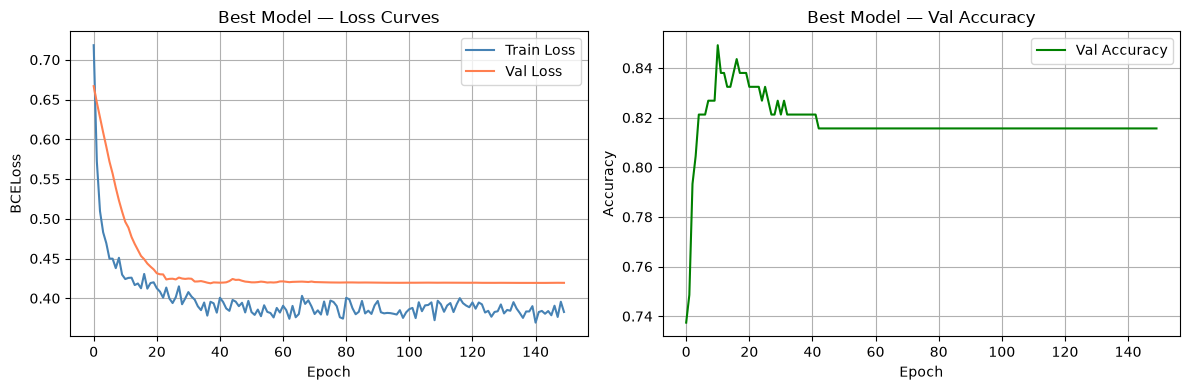


   DAY 3 FINAL RESULTS
  SGD final val loss     : 0.5886
  Adam final val loss    : 0.4225
  RMSprop final val loss : 0.4083
  Best model val acc     : 0.8492


In [21]:
print("=" * 55)
print("   BEST COMBINATION: RMSprop + ReduceLROnPlateau")
print("=" * 55)

# best combo from today's experiments:
# Optimizer: RMSprop (lowest val loss 0.4083)
# Activation: ReLU in hidden layers, Sigmoid at output
# LR: 0.001 with ReduceLROnPlateau

model_best = TitanicNetV2(input_size=8)
optimizer = optim.RMSprop(model_best.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=10, factor=0.5)
criterion = nn.BCELoss()

train_losses = []
val_losses   = []
val_accs     = []

for epoch in range(150):
    # training phase
    model_best.train()
    optimizer.zero_grad()
    train_preds = model_best(X_train_t)
    train_loss  = criterion(train_preds, y_train_t)
    train_loss.backward()
    optimizer.step()

    # validation phase
    model_best.eval()
    with torch.no_grad():
        val_preds = model_best(X_val_t)
        val_loss  = criterion(val_preds, y_val_t)
        val_acc   = ((val_preds > 0.5) == y_val_t.bool()).float().mean()

    scheduler.step(val_loss)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())
    val_accs.append(val_acc.item())

    if (epoch + 1) % 30 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d} | "
              f"Train Loss: {train_loss.item():.4f} | "
              f"Val Loss: {val_loss.item():.4f} | "
              f"Val Acc: {val_acc.item():.4f} | "
              f"LR: {current_lr:.6f}")

print(f"\nBest Val Accuracy : {max(val_accs):.4f} "
      f"at epoch {val_accs.index(max(val_accs))+1}")
print(f"Final Val Accuracy: {val_accs[-1]:.4f}")

# ── Plot final training curves ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, color='steelblue', label='Train Loss')
axes[0].plot(val_losses,   color='coral',     label='Val Loss')
axes[0].set_title('Best Model — Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCELoss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(val_accs, color='green', label='Val Accuracy')
axes[1].set_title('Best Model — Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('best_model_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Final comparison table ─────────────────────────────────────
print("\n" + "=" * 55)
print("   DAY 3 FINAL RESULTS")
print("=" * 55)
print(f"  SGD final val loss     : 0.5886")
print(f"  Adam final val loss    : 0.4225")
print(f"  RMSprop final val loss : 0.4083")
print(f"  Best model val acc     : {max(val_accs):.4f}")
print("=" * 55)